In [1]:
# import standard packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
from pathlib import Path
import dask.dataframe as dd
import cmocean
import xesmf as xe
import seaborn as sns
# import spatial packages
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rio
import seaborn as sns
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from dask.distributed import Client
from google.cloud import storage
import xskillscore
import numpy as np

# import statistical packages
from scipy.stats import linregress, pearsonr
from shapely.geometry import Point, mapping
from sklearn.metrics import mean_squared_error

try:
    import flox
except ImportError:
    print("[ACTEA_downscale] Warning: flox not installed - continuing without")

import sys
sys.path.append('../')
import ACTEA_stats
import ACTEA_gcs
gcs = ACTEA_gcs.ACTEA_gcs("monthly")
gcs.setup_actea_google_storage()
stats = ACTEA_stats.ACTEA_stats()
grouper = "time.month"


In [2]:
# Settings for the script
sns.set_style("white")
depth = 5.0
time="2018-01-01"
coarsen_step = 1
lat_lon_ext = [-182.+360, -154.+360, 50., 68.]

model = "CMCC-CM2-SR5"
basedir = f"dev/bias_test_cmcc/ssp585/{model}"
varnames = ["uo", "vo"]  # or "vo"

base_path=f"mCDR_validation/bias/{int(depth)}"
if not Path(base_path).exists():
    Path(base_path).mkdir(parents=True)

### Load the raw anomalies of CMCC and the downscaled Ba+SD data
Load the final dataset after downscaling the coarsened GLORYS12V1 dataset.

In [3]:
from matplotlib.ticker import FuncFormatter


def plot_map_glorys_or_actea_on_standard_grid(varname, da, lat_lon_ext, year="2015", producer="ACTEA"):
    
        da = da.assign_coords(lon=(np.mod(da.lon, 360))).sortby("lon")
    
        fig = plt.figure(figsize=[18,4])
        ax = fig.add_subplot(projection= ccrs.PlateCarree(central_longitude=180),facecolor='grey')
        da.plot(ax=ax,
                vmin=-0.25, vmax=0.25,
                cmap=cmocean.cm.balance, add_colorbar=True, transform=ccrs.PlateCarree())

        land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                edgecolor='face',
                                                facecolor="lightgrey")

        ax.coastlines()
        ax.add_feature(land_10m)
        ax.add_feature(cfeature.COASTLINE)
        ax.gridlines(color='black', alpha=0.5, linestyle='--')
        ax.set_extent(lat_lon_ext, crs=ccrs.PlateCarree(central_longitude=0))
        ax.set_xticks(da.lon.values[::3], crs=ccrs.PlateCarree(central_longitude=0))
        ax.set_yticks(da.lat.values[::3], crs=ccrs.PlateCarree(central_longitude=0))
        from matplotlib.ticker import FuncFormatter

        # Format tick labels to 2 decimals
        lon_formatter = FuncFormatter(lambda x, _: f'{180+x:.2f}E')
        ax.xaxis.set_major_formatter(lon_formatter)
        lat_formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
        ax.yaxis.set_major_formatter(lat_formatter)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

       # plt.title(f"{producer} grid {varname} {year}")
        plt.savefig(f"{base_path}/{producer}_{varname}_{year}.png", dpi=200, bbox_inches='tight')
        plt.show()

CMCC SD.    : uo ds size in MB 0.1614990234375
CMCC RAW    : uo ds size in MB 0.1614990234375
GLORYS full : uo ds size in MB 0.1614990234375
CMCC SD     : dimensions ('time', 'lat', 'lon'), shape Frozen({'time': 336, 'lat': 18, 'lon': 28})
CMCC RAW    : dimensions ('time', 'lat', 'lon'), shape Frozen({'time': 336, 'lat': 18, 'lon': 28})
GLORYS full : dimensions ('time', 'lat', 'lon'), shape Frozen({'time': 336, 'lat': 18, 'lon': 28})
Range of values CMCC SD -1.3093949366933761 1.3165063912029542


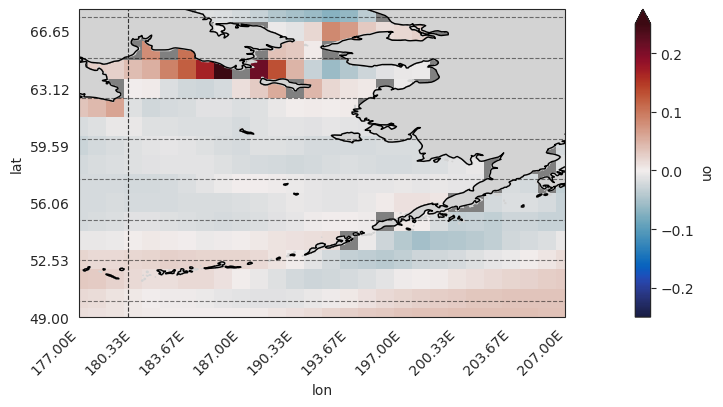

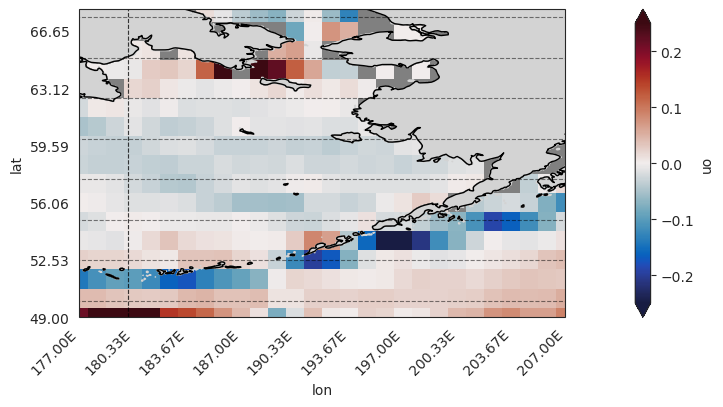

In [ ]:

for varname in varnames:
   
    glorys = f"glorys/bias_test_cmcc/timeseries_surface_{varname}_depth_{depth}m_216x336.nc"
    sd_cmcc = f"downscaling/bias_test_cmcc/ssp585/{model}/{varname}/{model}_r1i1p1f1_sd+ba_final_{varname}_surface_depth_{depth}_0_final.nc"
    cmcc_raw = f"downscaling/bias_test_cmcc/ssp585/{model}/{varname}/{model}_r1i1p1f1_{varname}_surface_raw.nc"   

    coarsen_step = 6
    ds_raw_cmcc = gcs.open_dataset_on_gs(cmcc_raw)
    ds_glorys = gcs.open_dataset_on_gs(glorys).coarsen(lat=coarsen_step, lon=coarsen_step, boundary="pad").mean()
    ds_sd_cmcc = gcs.open_dataset_on_gs(sd_cmcc).coarsen(lat=coarsen_step, lon=coarsen_step, boundary="pad").mean() 

    ds_raw_cmcc_int = ds_raw_cmcc[varname]
    ds_glorys_int = ds_glorys[varname].interp_like(ds_raw_cmcc_int, method="linear", kwargs={"fill_value": "extrapolate"})
    ds_sd_cmcc_int = ds_sd_cmcc[varname].interp_like(ds_raw_cmcc_int, method="linear", kwargs={"fill_value": "extrapolate"})
       
    clim_glorys_int = stats.calculate_detrended_climatology(
            ds_glorys_int, varname, grouper)

    clim_cmcc_int = stats.calculate_detrended_climatology(
            ds_sd_cmcc_int, varname, grouper)

   # ds_raw_cmcc_int = ds_raw_cmcc_int.groupby(grouper) - clim_glorys_int
   # ds_sd_cmcc_int = ds_sd_cmcc_int.groupby(grouper) - clim_glorys_int
   # ds_raw_cmcc_int = ds_raw_cmcc_int[varname].chunk({"time": -1, "lat": -1, "lon": -1})
   # ds_sd_cmcc_int = ds_sd_cmcc_int[varname].chunk({"time": -1, "lat": -1, "lon": -1})
    
    print(f"CMCC SD.    : {varname} ds size in MB", ds_sd_cmcc_int.size / (1024*1024))
    print(f"CMCC RAW    : {varname} ds size in MB", ds_raw_cmcc_int.size / (1024*1024))
    print(f"GLORYS full : {varname} ds size in MB", ds_glorys_int.size / (1024*1024))
 
    print(f"CMCC SD     : dimensions {ds_sd_cmcc_int.dims}, shape {ds_sd_cmcc_int.sizes}")
    print(f"CMCC RAW    : dimensions {ds_raw_cmcc_int.dims}, shape {ds_raw_cmcc_int.sizes}")
    print(f"GLORYS full : dimensions {ds_glorys_int.dims}, shape {ds_glorys_int.sizes}")
   
    period1_start = "1993-01-01"
    period1_end = "2015-12-31"
    period2_start = "2015-01-01"
    period2_end = "2020-12-31"
    print(f"Range of values CMCC SD {ds_sd_cmcc_int.min().values} {ds_sd_cmcc_int.max().values}")

    plot_map_glorys_or_actea_on_standard_grid(varname, ds_raw_cmcc_int.sel(time=slice(period1_start, period1_end)).mean(dim="time"), lat_lon_ext, year=f"{period1_start} to {period1_end}", producer="Mean CMCC raw")
    plot_map_glorys_or_actea_on_standard_grid(varname, ds_sd_cmcc_int.sel(time=slice(period1_start, period1_end)).mean(dim="time"), lat_lon_ext, year=f"{period1_start} to {period1_end}", producer="Mean CMCC final")
    plot_map_glorys_or_actea_on_standard_grid(varname, ds_glorys_int.sel(time=slice(period1_start, period1_end)).mean(dim="time"), lat_lon_ext, year=f"{period1_start} to {period1_end}", producer="Mean GLORYS")


    # STEPS
    # Find the difference between coarse and raw CMCC and coarsened glorys: training period
    rmse1 = xskillscore.mae(ds_raw_cmcc_int.sel(time=slice(period1_start, period1_end)), 
                            ds_glorys_int.sel(time=slice(period1_start, period1_end)), dim="time")
    plot_map_glorys_or_actea_on_standard_grid(varname, rmse1, lat_lon_ext, year=f"{period1_start} to {period1_end}", producer="MAE CMCC RAW")
    
    # Find the difference between coarsened CMCC and coarsened GLORYS: training period
    rmse2 = xskillscore.mae(ds_raw_cmcc_int.sel(time=slice(period2_start, period2_end)), 
                            ds_glorys_int.sel(time=slice(period2_start, period2_end)), dim="time")
    plot_map_glorys_or_actea_on_standard_grid(varname, rmse2, lat_lon_ext, year=f"{period2_start} to {period2_end}", producer="MAE CMCC RAW")

    # Find the difference between coarse and raw CMCC and coarsened glorys: validation period
    rmse3 = xskillscore.mae(ds_sd_cmcc_int.sel(time=slice(period1_start, period1_end)), 
                            ds_glorys_int.sel(time=slice(period1_start, period1_end)), dim="time")
    plot_map_glorys_or_actea_on_standard_grid(varname, rmse3, lat_lon_ext, year=f"{period1_start} to {period1_end}", producer="MAE CMCC SD")

    # Find the difference between coarsened CMCC and coarsened GLORYS: validation period
    rmse4 = xskillscore.mae(ds_sd_cmcc_int.sel(time=slice(period2_start, period2_end)), 
                            ds_glorys_int.sel(time=slice(period2_start, period2_end)), dim="time")
    plot_map_glorys_or_actea_on_standard_grid(varname, rmse4, lat_lon_ext, year=f"{period2_start} to {period2_end}", producer="MAE CMCC SD")

    print(f"RMSE1: {rmse1.mean().values}, RMSE2: {rmse2.mean().values}, RMSE3: {rmse3.mean().values}, RMSE4: {rmse4.mean().values}")

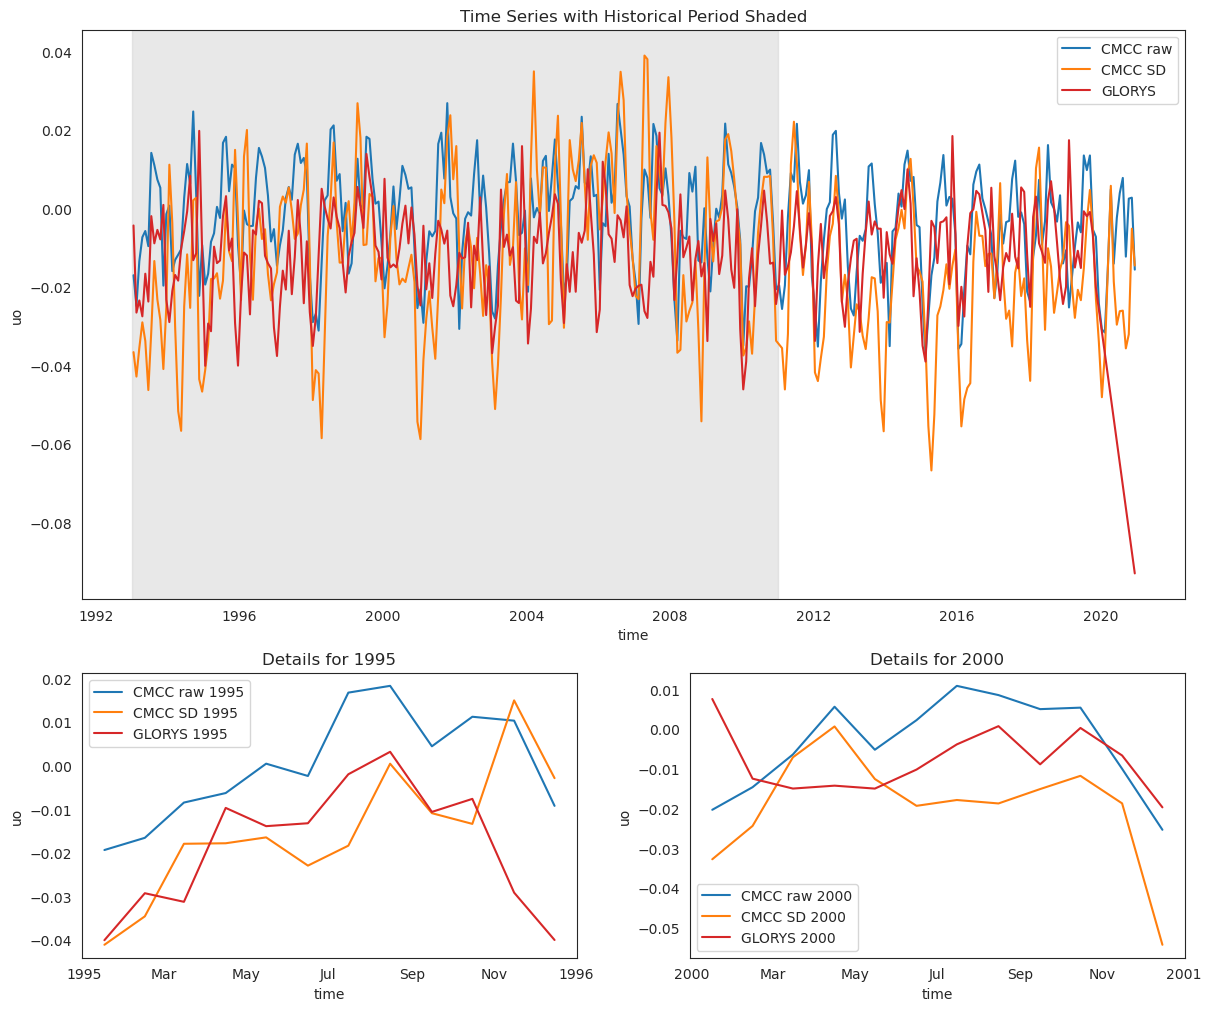

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume ds_raw_cmcc_int, ds_sd_cmcc_int, ds_glorys_int are xarray DataArrays with a 'time' dimension

fig = plt.figure(constrained_layout=True, figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# Main plot (top, spanning both columns)
ax_main = fig.add_subplot(gs[0, :])
ds_raw_cmcc_int.mean(dim=["lat","lon"]).plot(ax=ax_main, color="tab:blue", label="CMCC raw")
ds_sd_cmcc_int.mean(dim=["lat","lon"]).plot(ax=ax_main, color="tab:orange", label="CMCC SD")
ds_glorys_int.mean(dim=["lat","lon"]).plot(ax=ax_main, color="tab:red", label="GLORYS")
ax_main.axvspan(pd.Timestamp('1993-01-01'), pd.Timestamp('2010-12-31'), color='lightgrey', alpha=0.5)
ax_main.set_facecolor('white')
ax_main.set_title('Time Series with Historical Period Shaded')
ax_main.legend()

# Zoomed-in plots (bottom row, side by side)
years = ['1999', '2014']
for i, year in enumerate(years):
    ax = fig.add_subplot(gs[1, i])
    ds_raw_cmcc_int.sel(time=slice(f'{year}-01-01', f'{year}-12-31')).mean(dim=["lat","lon"]).plot(ax=ax, color="tab:blue", label=f"CMCC raw {year}")
    ds_sd_cmcc_int.sel(time=slice(f'{year}-01-01', f'{year}-12-31')).mean(dim=["lat","lon"]).plot(ax=ax, color="tab:orange", label=f"CMCC SD {year}")
    ds_glorys_int.sel(time=slice(f'{year}-01-01', f'{year}-12-31')).mean(dim=["lat","lon"]).plot(ax=ax, color="tab:red", label=f"GLORYS {year}")
    ax.set_title(f'Details for {year}')
    ax.legend()
   # Optional: To visually match the x-axis range to the main plot, set the same limits if desired
  #  ax.set_xlim(ax_main.get_xlim())
  #  ax.set_ylim(ax_main.get_ylim())

plt.show()

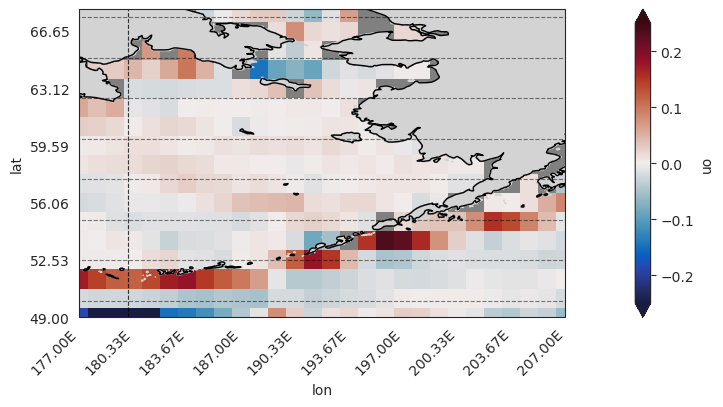

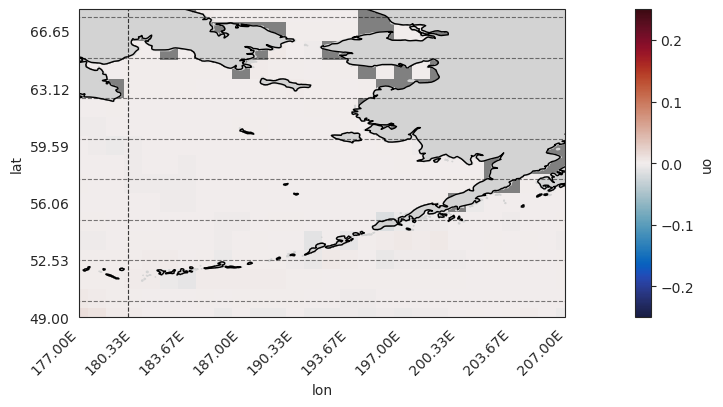

Overall bias period 1 CMCC RAW:  0.009807286250192428
Overall bias period 1 CMCC SD:  -0.0005333470027476594


In [ ]:
bias_raw = (ds_raw_cmcc_int- ds_glorys_int).sel(time=slice(period1_start, period1_end)).mean(dim="time")
bias_sd = (ds_sd_cmcc_int- ds_glorys_int).sel(time=slice(period1_start, period1_end)).mean(dim="time")
plot_map_glorys_or_actea_on_standard_grid(varname, bias_raw, lat_lon_ext, year=f"{period1_start} to {period1_end}", producer="Bias CMCC RAW")
plot_map_glorys_or_actea_on_standard_grid(varname, bias_sd, lat_lon_ext, year=f"{period1_start} to {period1_end}", producer="Bias CMCC SD")
print("Overall bias period 1 CMCC RAW: ", bias_raw.mean().values)
print("Overall bias period 1 CMCC SD: ", bias_sd.mean().values)

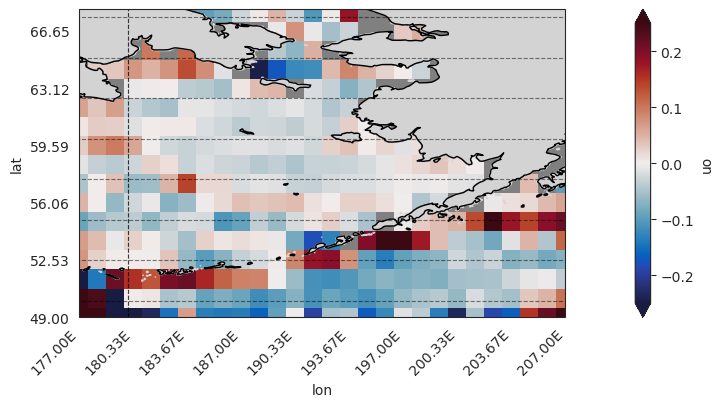

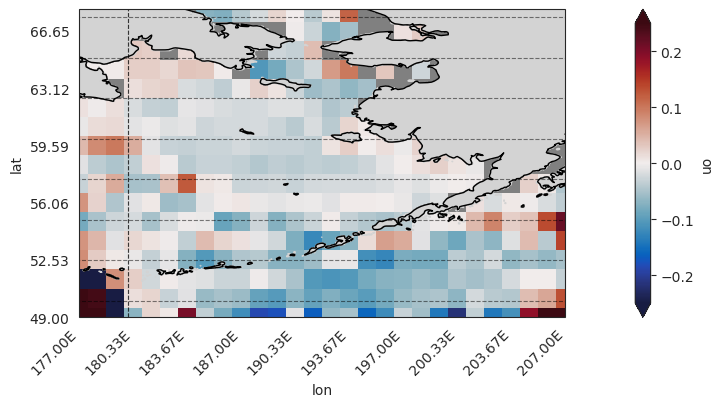

Overall bias period 2 CMCC RAW:  0.012058602929247902
Overall bias period 2 CMCC SD:  -0.0029751149243234837


In [ ]:
bias_raw = (ds_raw_cmcc_int- ds_glorys_int).sel(time=slice(period2_start, period2_end)).mean(dim="time")
bias_sd = (ds_sd_cmcc_int- ds_glorys_int).sel(time=slice(period2_start, period2_end)).mean(dim="time")
plot_map_glorys_or_actea_on_standard_grid(varname, bias_raw, lat_lon_ext, year=f"{period2_start} to {period2_end}", producer="Bias CMCC RAW")
plot_map_glorys_or_actea_on_standard_grid(varname, bias_sd, lat_lon_ext, year=f"{period2_start} to {period2_end}", producer="Bias CMCC SD")
print("Overall bias period 2 CMCC RAW: ", bias_raw.mean().values)
print("Overall bias period 2 CMCC SD: ", bias_sd.mean().values)